# MNIST Model Comparison

This notebook compares model complexity on MNIST, moving from linear baselines to classic non-linear methods and then to neural networks and CNNs.

Goals:
- See how accuracy changes as models get more expressive.
- Use the same evaluation for every model.
- Understand typical errors through confusion matrices and misclassified examples.

Expectation: linear models should be solid but limited, while CNNs should perform best by using spatial structure.

In [1]:
# Standard library for reproducibility
import random
import numpy as np
import matplotlib.pyplot as plt

# Sklearn tools for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier

import pandas as pd

# PyTorch for neural network models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Keras interface for loading MNIST
from tensorflow.keras.datasets import mnist

# Set all random seeds for reproducibility across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make PyTorch operations deterministic (may reduce performance slightly)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Create a numpy random generator instance for consistent sampling
RNG = np.random.default_rng(SEED)

In [2]:
# Load MNIST from Keras (60k train, 10k test)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1] range for stable training
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Flatten for traditional ML models (28x28 -> 784)
X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

# Add channel dimension for CNNs (N, 28, 28) -> (N, 1, 28, 28)
X_train_img = torch.from_numpy(X_train).unsqueeze(1).float()
X_test_img = torch.from_numpy(X_test).unsqueeze(1).float()

# Convert labels to PyTorch tensors
y_train_t = torch.from_numpy(y_train).long()
y_test_t = torch.from_numpy(y_test).long()

print("X_train:", X_train.shape, X_train.dtype)
print("X_test:", X_test.shape, X_test.dtype)
print("X_train_flat:", X_train_flat.shape, X_train_flat.dtype)
print("X_train_img:", X_train_img.shape, X_train_img.dtype)
print("Pixel range:", X_train.min(), "to", X_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28) float32
X_test: (10000, 28, 28) float32
X_train_flat: (60000, 784) float32
X_train_img: torch.Size([60000, 1, 28, 28]) torch.float32
Pixel range: 0.0 to 1.0


In [3]:
def plot_confusion_matrix(y_true, y_pred, title):
    """Display a confusion matrix heatmap; diagonals are correct predictions."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(10))
    ax.set_yticks(np.arange(10))
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def show_misclassified_examples(images, y_true, y_pred, n=20, title=""):
    """Show a reproducible sample of misclassified images with predicted/true labels."""
    mis_idx = np.where(y_true != y_pred)[0]
    if len(mis_idx) == 0:
        print("No misclassified examples to show.")
        return

    n = min(n, len(mis_idx))
    # Sample using the seeded RNG so results are stable across runs
    chosen = RNG.choice(mis_idx, size=n, replace=False)

    cols = 5
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(10, 2 * rows))
    for i, idx in enumerate(chosen, start=1):
        plt.subplot(rows, cols, i)
        plt.imshow(images[idx], cmap="gray")
        plt.title(f"p={y_pred[idx]}, t={y_true[idx]}")
        plt.axis("off")
    if title:
        plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def evaluate_classifier(name, y_true, y_pred):
    """Print accuracy, classification report, and confusion matrix; return accuracy."""
    acc = accuracy_score(y_true, y_pred)
    print(f"{name} accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    plot_confusion_matrix(y_true, y_pred, title=f"{name} Confusion Matrix")
    return acc

## Baseline 0: Dummy classifier (most frequent)

This baseline always predicts the most common digit. It is a sanity check that tells us how much better real models are than a trivial guess.

Dummy (most frequent) accuracy: 0.1135
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       980
           1     0.1135    1.0000    0.2039      1135
           2     0.0000    0.0000    0.0000      1032
           3     0.0000    0.0000    0.0000      1010
           4     0.0000    0.0000    0.0000       982
           5     0.0000    0.0000    0.0000       892
           6     0.0000    0.0000    0.0000       958
           7     0.0000    0.0000    0.0000      1028
           8     0.0000    0.0000    0.0000       974
           9     0.0000    0.0000    0.0000      1009

    accuracy                         0.1135     10000
   macro avg     0.0114    0.1000    0.0204     10000
weighted avg     0.0129    0.1135    0.0231     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


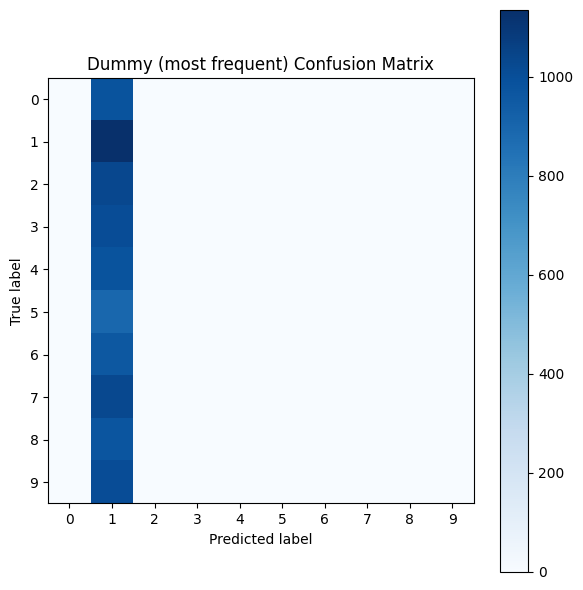

In [4]:
# Track results for all models in a list of dictionaries
results = []

# Baseline 0: always predict the most frequent class (digit 1 in MNIST)
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train_flat, y_train)

y_pred_dummy = dummy.predict(X_test_flat)
acc_dummy = evaluate_classifier("Dummy (most frequent)", y_test, y_pred_dummy)
results.append({
    "Model": "Dummy (most frequent)",
    "Test Accuracy": acc_dummy,
    "Macro F1": f1_score(y_test, y_pred_dummy, average="macro"),
})

## Baseline 1: Logistic Regression (multinomial)

A linear model that estimates class probabilities. It is a strong baseline on raw pixels but cannot model complex spatial patterns.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression accuracy: 0.9239
              precision    recall  f1-score   support

           0     0.9540    0.9724    0.9631       980
           1     0.9588    0.9833    0.9709      1135
           2     0.9245    0.9021    0.9132      1032
           3     0.8977    0.9040    0.9008      1010
           4     0.9348    0.9338    0.9343       982
           5     0.8956    0.8756    0.8855       892
           6     0.9313    0.9478    0.9395       958
           7     0.9305    0.9251    0.9278      1028
           8     0.8942    0.8768    0.8854       974
           9     0.9077    0.9068    0.9073      1009

    accuracy                         0.9239     10000
   macro avg     0.9229    0.9228    0.9228     10000
weighted avg     0.9236    0.9239    0.9237     10000



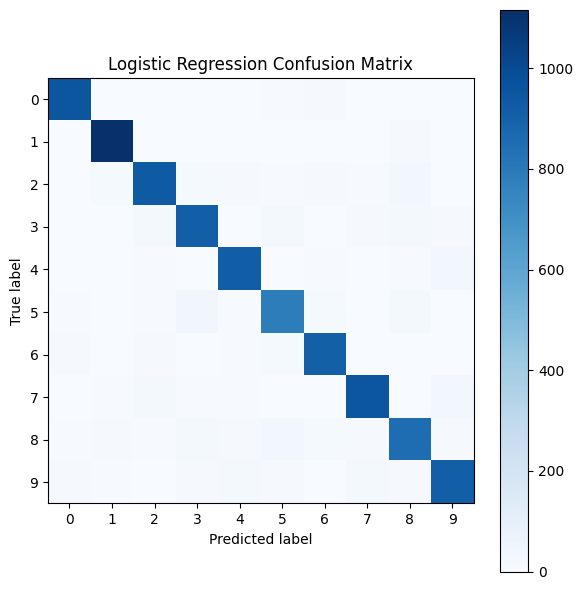

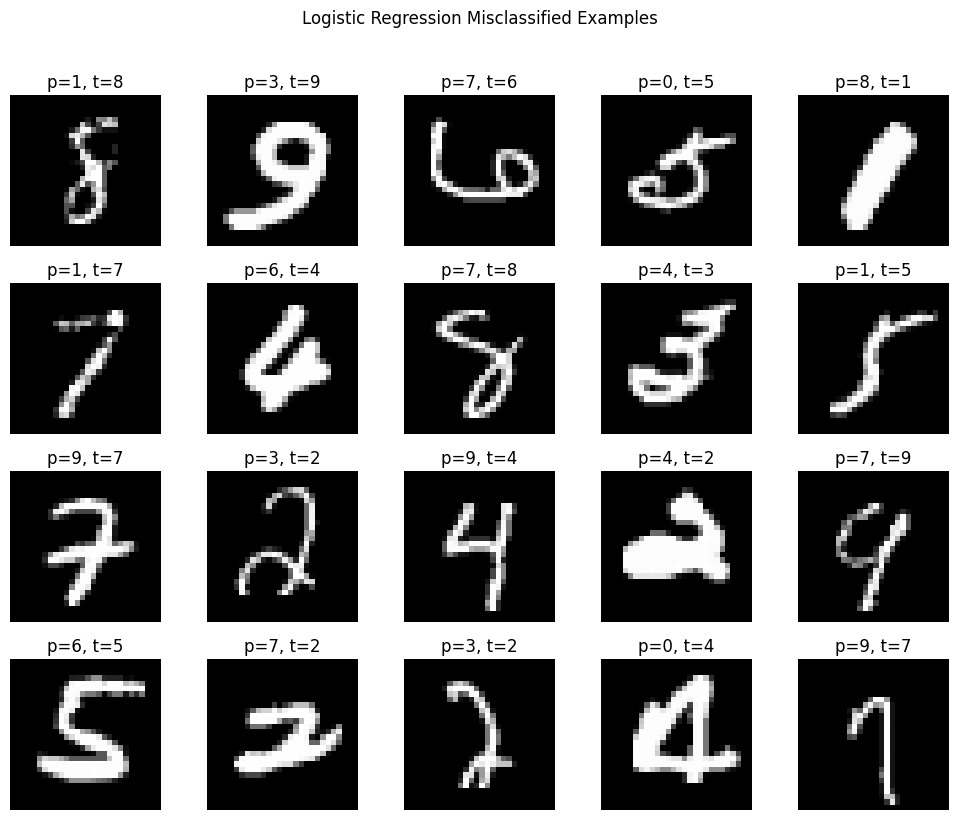

In [5]:
# Optionally limit training samples to speed up experimentation
max_train_samples = 40000  # Set to None to use the full training set
if max_train_samples is not None:
    X_train_lr = X_train_flat[:max_train_samples]
    y_train_lr = y_train[:max_train_samples]
else:
    X_train_lr = X_train_flat
    y_train_lr = y_train

# Baseline 1: multinomial logistic regression (one-vs-rest softmax)
# lbfgs: quasi-Newton solver; fast and stable for medium datasets
# multi_class="multinomial": trains a true softmax (not one-vs-rest)
# max_iter: upper bound on solver steps; typically converges sooner
# n_jobs: use all CPU cores to speed up fitting
log_reg = LogisticRegression(
    solver="lbfgs",
    multi_class="multinomial",
    max_iter=200,
    n_jobs=-1,
    random_state=SEED,
)
log_reg.fit(X_train_lr, y_train_lr)

y_pred_lr = log_reg.predict(X_test_flat)
acc_lr = evaluate_classifier("Logistic Regression", y_test, y_pred_lr)
results.append({
    "Model": "Logistic Regression",
    "Test Accuracy": acc_lr,
    "Macro F1": f1_score(y_test, y_pred_lr, average="macro"),
})

# Show examples that logistic regression got wrong
show_misclassified_examples(
    X_test,
    y_test,
    y_pred_lr,
    n=20,
    title="Logistic Regression Misclassified Examples",
)

In [6]:
# Check GPU availability and details; prints once per session
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")  # CUDA toolkit linked in this build
    print(f"GPU name: {torch.cuda.get_device_name(0)}")  # Active device label
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA version: 12.6
GPU name: Tesla T4
GPU memory: 15.83 GB


## Baseline 2: Linear classifier with SGD

Stochastic gradient descent scales well to large datasets and is a common way to train linear models quickly.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGD Classifier (log loss) accuracy: 0.9141
              precision    recall  f1-score   support

           0     0.9286    0.9827    0.9549       980
           1     0.9677    0.9753    0.9715      1135
           2     0.9246    0.8915    0.9077      1032
           3     0.8596    0.9218    0.8896      1010
           4     0.9197    0.9328    0.9262       982
           5     0.8869    0.8442    0.8650       892
           6     0.9417    0.9447    0.9432       958
           7     0.9329    0.9066    0.9196      1028
           8     0.8961    0.8326    0.8632       974
           9     0.8758    0.8949    0.8853      1009

    accuracy                         0.9141     10000
   macro avg     0.9134    0.9127    0.9126     10000
weighted avg     0.9143    0.9141    0.9138     10000



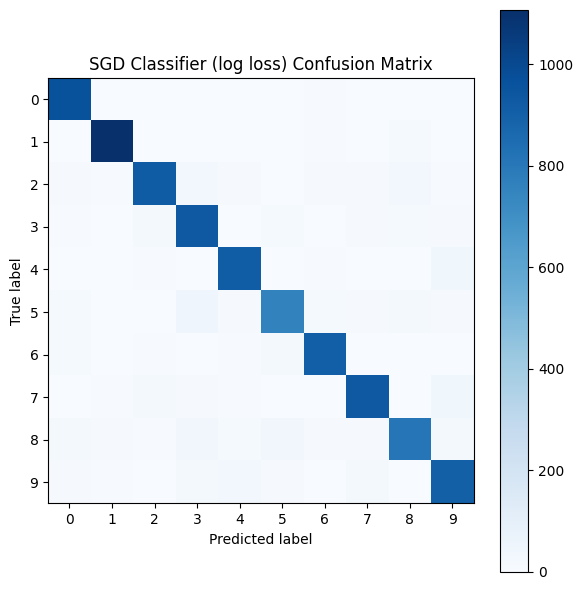

In [7]:
# Baseline 2: linear model trained with stochastic gradient descent
# loss="log_loss": equivalent to logistic regression loss
# alpha: L2 regularization strength (higher = more regularization)
# max_iter/tol: stop when convergence is reached or iterations exceed max_iter
sgd_clf = SGDClassifier(
    loss="log_loss",
    max_iter=20,
    tol=1e-3,
    alpha=1e-4,
    random_state=SEED,
)
sgd_clf.fit(X_train_flat, y_train)

y_pred_sgd = sgd_clf.predict(X_test_flat)
acc_sgd = evaluate_classifier("SGD Classifier (log loss)", y_test, y_pred_sgd)
results.append({
    "Model": "SGD Classifier (log loss)",
    "Test Accuracy": acc_sgd,
    "Macro F1": f1_score(y_test, y_pred_sgd, average="macro"),
})

## Classic ML 1: k-Nearest Neighbors

KNN uses local similarity and can be very accurate, but it is slow at inference because it compares a test point to many training points.

k=3 test accuracy: 0.9705
k=5 test accuracy: 0.9688
Using k=3 for detailed evaluation.
KNN (k=3) accuracy: 0.9705
              precision    recall  f1-score   support

           0     0.9663    0.9939    0.9799       980
           1     0.9577    0.9982    0.9776      1135
           2     0.9822    0.9651    0.9736      1032
           3     0.9635    0.9663    0.9649      1010
           4     0.9754    0.9674    0.9714       982
           5     0.9663    0.9630    0.9646       892
           6     0.9833    0.9854    0.9844       958
           7     0.9649    0.9640    0.9645      1028
           8     0.9892    0.9384    0.9631       974
           9     0.9603    0.9594    0.9598      1009

    accuracy                         0.9705     10000
   macro avg     0.9709    0.9701    0.9704     10000
weighted avg     0.9707    0.9705    0.9705     10000



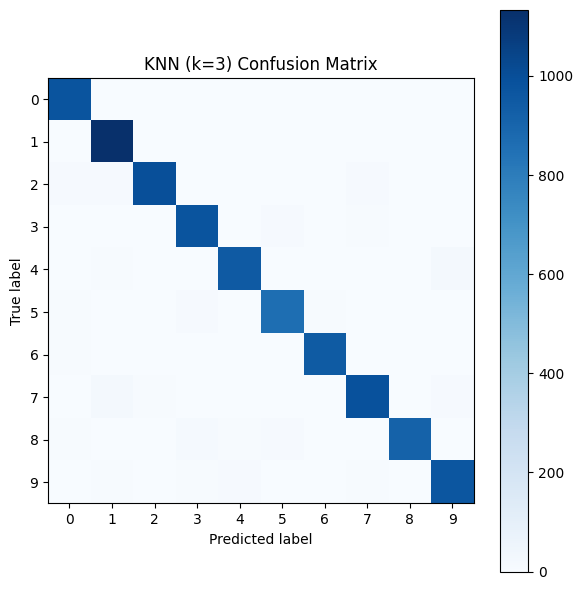

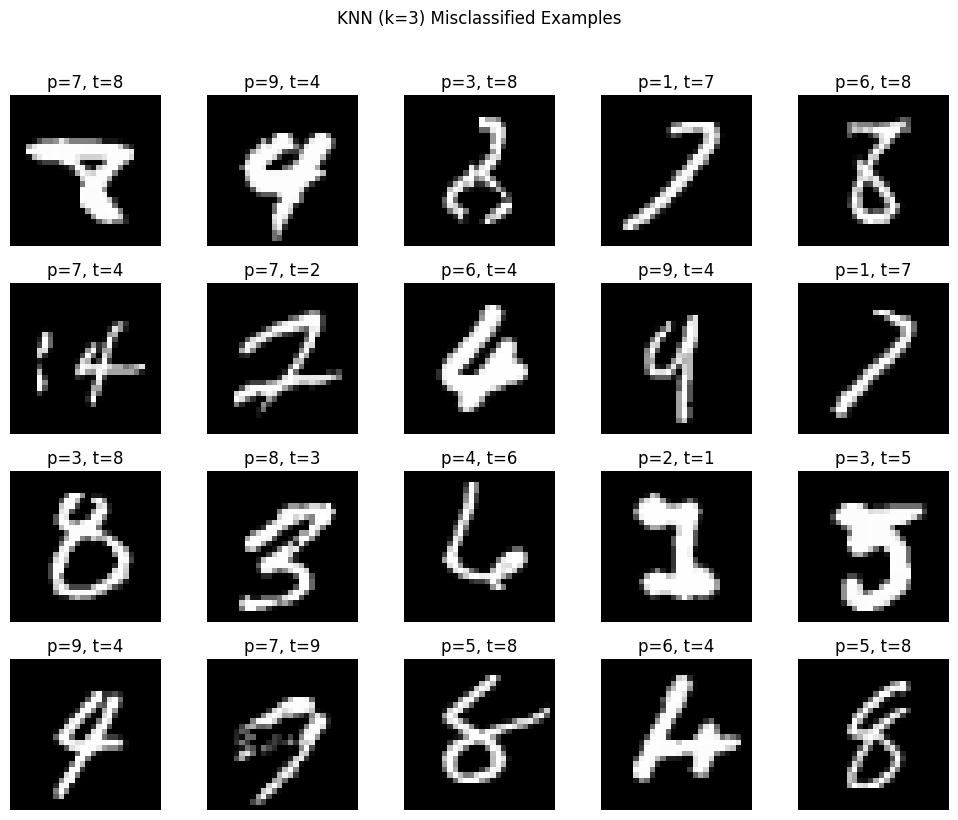

In [8]:
# Classic ML 1: k-Nearest Neighbors (instance-based, non-parametric)
# k_values: small ks reduce bias but can be noisy; we grid-search 3 and 5
k_values = [3, 5]
knn_results = []
knn_preds = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)``````
    # KNN stores all training samples; prediction is majority vote among k nearest
    knn.fit(X_train_flat, y_train)
    y_pred_knn = knn.predict(X_test_flat)
    acc_knn = accuracy_score(y_test, y_pred_knn)
    knn_results.append((k, acc_knn))
    knn_preds[k] = y_pred_knn
    print(f"k={k} test accuracy: {acc_knn:.4f}")

# Select the k value with highest test accuracy
best_k, _ = max(knn_results, key=lambda x: x[1])
print(f"Using k={best_k} for detailed evaluation.")

y_pred_knn_best = knn_preds[best_k]
acc_knn_best = evaluate_classifier(f"KNN (k={best_k})", y_test, y_pred_knn_best)
results.append({
    "Model": f"KNN (k={best_k})",
    "Test Accuracy": acc_knn_best,
    "Macro F1": f1_score(y_test, y_pred_knn_best, average="macro"),
})

show_misclassified_examples(
    X_test,
    y_test,
    y_pred_knn_best,
    n=20,
    title=f"KNN (k={best_k}) Misclassified Examples",
)

## Classic ML 2: PCA + Logistic Regression

PCA reduces dimensionality by keeping directions of greatest variance. It can speed up training and sometimes improve generalization by removing noise.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


PCA components=50 test accuracy: 0.9130


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


PCA components=100 test accuracy: 0.9213


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


PCA components=200 test accuracy: 0.9265
Using 200 PCA components for detailed evaluation.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


PCA(200) + Logistic Regression accuracy: 0.9265
              precision    recall  f1-score   support

           0     0.9550    0.9735    0.9641       980
           1     0.9661    0.9780    0.9720      1135
           2     0.9306    0.9089    0.9196      1032
           3     0.9084    0.9129    0.9106      1010
           4     0.9307    0.9297    0.9302       982
           5     0.9058    0.8733    0.8893       892
           6     0.9405    0.9562    0.9482       958
           7     0.9306    0.9261    0.9283      1028
           8     0.8774    0.8891    0.8832       974
           9     0.9114    0.9068    0.9091      1009

    accuracy                         0.9265     10000
   macro avg     0.9256    0.9254    0.9255     10000
weighted avg     0.9264    0.9265    0.9264     10000



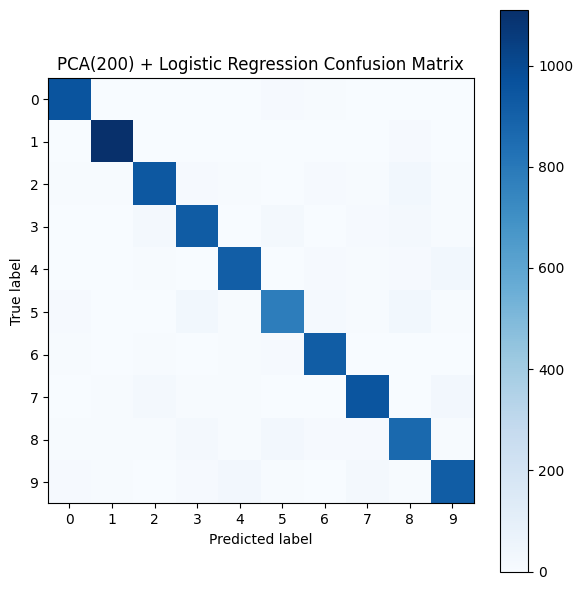

In [9]:
# Classic ML 2: dimensionality reduction + linear model
# PCA reduces dimensionality; logistic regression then classifies in the reduced space
pca_components_list = [50, 100, 200]
pca_scores = []

for n_components in pca_components_list:
    # svd_solver="randomized": faster approximate SVD for large matrices
    pca = PCA(n_components=n_components, random_state=SEED, svd_solver="randomized")
    X_train_pca = pca.fit_transform(X_train_flat)
    X_test_pca = pca.transform(X_test_flat)

    lr_pca = LogisticRegression(
        solver="lbfgs",          # Stable for smaller feature spaces
        multi_class="multinomial",# True softmax training
        max_iter=300,             # Generous cap; usually converges sooner
        n_jobs=-1,                # Use all CPU cores
        random_state=SEED,
    )
    lr_pca.fit(X_train_pca, y_train)
    y_pred_pca = lr_pca.predict(X_test_pca)
    acc_pca = accuracy_score(y_test, y_pred_pca)
    pca_scores.append((n_components, acc_pca))
    print(f"PCA components={n_components} test accuracy: {acc_pca:.4f}")

# Choose number of components that gave best test accuracy
chosen_components = max(pca_scores, key=lambda x: x[1])[0]
print(f"Using {chosen_components} PCA components for detailed evaluation.")

# Refit with chosen components for full evaluation
pca = PCA(n_components=chosen_components, random_state=SEED, svd_solver="randomized")
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

lr_pca = LogisticRegression(
    solver="lbfgs",
    multi_class="multinomial",
    max_iter=300,
    n_jobs=-1,
    random_state=SEED,
)
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)
acc_pca = evaluate_classifier(
    f"PCA({chosen_components}) + Logistic Regression", y_test, y_pred_pca
)
results.append({
    "Model": f"PCA({chosen_components}) + Logistic Regression",
    "Test Accuracy": acc_pca,
    "Macro F1": f1_score(y_test, y_pred_pca, average="macro"),
})

## Why deep learning and CNNs

Flattening images treats each pixel independently and ignores spatial structure like edges and strokes. Neural networks can learn non-linear combinations of pixels, and CNNs go further by using local filters and weight sharing to detect patterns wherever they appear. We expect better accuracy and more consistent error patterns.

## Deep Learning 1: Simple MLP (PyTorch)

A multi-layer perceptron can learn non-linear decision boundaries, but it still sees a flattened image. This should outperform linear models but not reach CNN performance.

Device: cuda
Epoch 1/20 - loss: 0.3824 - test acc: 0.9516
Epoch 2/20 - loss: 0.1527 - test acc: 0.9680
Epoch 3/20 - loss: 0.1082 - test acc: 0.9762
Epoch 4/20 - loss: 0.0850 - test acc: 0.9756
Epoch 5/20 - loss: 0.0705 - test acc: 0.9788
Epoch 6/20 - loss: 0.0589 - test acc: 0.9776
Epoch 7/20 - loss: 0.0517 - test acc: 0.9814
Epoch 8/20 - loss: 0.0464 - test acc: 0.9795
Epoch 9/20 - loss: 0.0388 - test acc: 0.9817
Epoch 10/20 - loss: 0.0344 - test acc: 0.9800
Epoch 11/20 - loss: 0.0342 - test acc: 0.9828
Epoch 12/20 - loss: 0.0304 - test acc: 0.9808
Epoch 13/20 - loss: 0.0295 - test acc: 0.9842
Epoch 14/20 - loss: 0.0268 - test acc: 0.9818
Epoch 15/20 - loss: 0.0249 - test acc: 0.9816
Epoch 16/20 - loss: 0.0238 - test acc: 0.9811
Epoch 17/20 - loss: 0.0225 - test acc: 0.9847
Epoch 18/20 - loss: 0.0191 - test acc: 0.9814
Epoch 19/20 - loss: 0.0223 - test acc: 0.9806
Epoch 20/20 - loss: 0.0213 - test acc: 0.9833


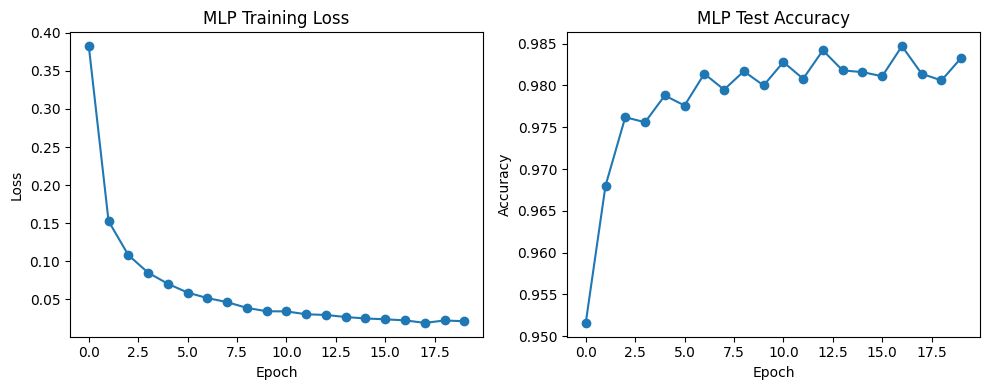

MLP accuracy: 0.9833
              precision    recall  f1-score   support

           0     0.9918    0.9908    0.9913       980
           1     0.9929    0.9912    0.9921      1135
           2     0.9911    0.9719    0.9814      1032
           3     0.9671    0.9891    0.9780      1010
           4     0.9877    0.9827    0.9852       982
           5     0.9788    0.9854    0.9821       892
           6     0.9854    0.9843    0.9849       958
           7     0.9844    0.9796    0.9820      1028
           8     0.9774    0.9784    0.9779       974
           9     0.9753    0.9792    0.9773      1009

    accuracy                         0.9833     10000
   macro avg     0.9832    0.9833    0.9832     10000
weighted avg     0.9834    0.9833    0.9833     10000



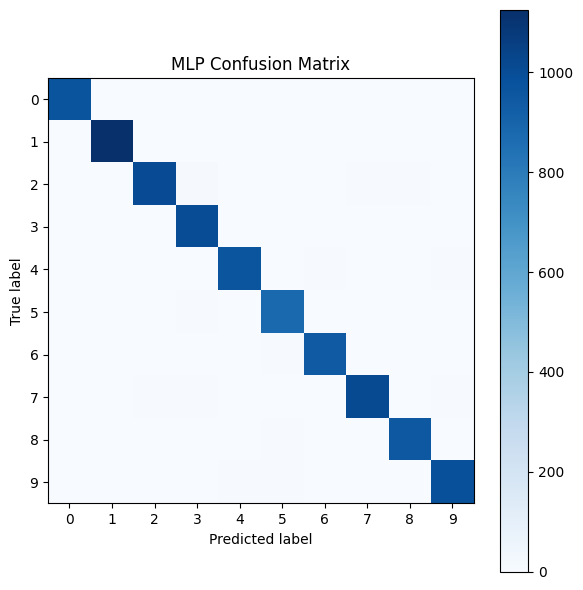

In [14]:
# Determine if GPU is available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

batch_size = 128  # Larger batches improve throughput on GPU; still fine on CPU

# Create PyTorch datasets and loaders for efficient batching
train_ds_flat = TensorDataset(
    torch.from_numpy(X_train_flat).float(),  # Features as float32
    torch.from_numpy(y_train).long(),        # Labels as int64
)
test_ds_flat = TensorDataset(
    torch.from_numpy(X_test_flat).float(),
    torch.from_numpy(y_test).long(),
)

train_loader_flat = DataLoader(train_ds_flat, batch_size=batch_size, shuffle=True)
test_loader_flat = DataLoader(test_ds_flat, batch_size=batch_size, shuffle=False)


def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one pass over loader and return average loss."""
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        # Accumulate loss scaled by batch size for proper averaging
        running_loss += loss.item() * batch_x.size(0)

    return running_loss / len(loader.dataset)


def evaluate_accuracy(model, loader, device):
    """Compute accuracy without gradient updates (eval mode)."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            logits = model(batch_x)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
    return correct / total


class MLP(nn.Module):
    """Two-hidden-layer MLP with dropout to combat overfitting."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),   # Input: 28*28 flattened pixels
            nn.ReLU(),
            nn.Dropout(0.2),       # Drop 20% of activations
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),   # 10 classes for digits
        )

    def forward(self, x):
        return self.net(x)


# Initialize model, loss function, and optimizer
mlp = MLP().to(device)
criterion = nn.CrossEntropyLoss()               # Multiclass log-loss
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)  # Adaptive optimizer, good default

epochs = 20
mlp_train_losses = []
mlp_test_accs = []

# Train for several epochs and track metrics
for epoch in range(1, epochs + 1):
    loss = train_one_epoch(mlp, train_loader_flat, criterion, optimizer, device)
    acc = evaluate_accuracy(mlp, test_loader_flat, device)
    mlp_train_losses.append(loss)
    mlp_test_accs.append(acc)
    print(f"Epoch {epoch}/{epochs} - loss: {loss:.4f} - test acc: {acc:.4f}")

# Plot training progress
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(mlp_train_losses, marker="o")
plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(mlp_test_accs, marker="o")
plt.title("MLP Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

# Collect all predictions for detailed evaluation
mlp.eval()
all_preds = []
all_true = []
with torch.no_grad():
    for batch_x, batch_y in test_loader_flat:
        batch_x = batch_x.to(device)
        logits = mlp(batch_x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(batch_y.numpy())

y_pred_mlp = np.concatenate(all_preds)
y_true_mlp = np.concatenate(all_true)

acc_mlp = evaluate_classifier("MLP", y_true_mlp, y_pred_mlp)
results.append({
    "Model": "MLP",
    "Test Accuracy": acc_mlp,
    "Macro F1": f1_score(y_true_mlp, y_pred_mlp, average="macro"),
})

## Deep Learning 2: Simple CNN (PyTorch)

A CNN uses local filters and shared weights, which are well-suited to images. This should give the best performance among the models here.

Epoch 1/20 - loss: 0.3040 - test acc: 0.9793
Epoch 2/20 - loss: 0.0845 - test acc: 0.9857
Epoch 3/20 - loss: 0.0604 - test acc: 0.9877
Epoch 4/20 - loss: 0.0476 - test acc: 0.9905
Epoch 5/20 - loss: 0.0402 - test acc: 0.9899
Epoch 6/20 - loss: 0.0345 - test acc: 0.9912
Epoch 7/20 - loss: 0.0290 - test acc: 0.9910
Epoch 8/20 - loss: 0.0250 - test acc: 0.9904
Epoch 9/20 - loss: 0.0234 - test acc: 0.9908
Epoch 10/20 - loss: 0.0212 - test acc: 0.9922
Epoch 11/20 - loss: 0.0181 - test acc: 0.9919
Epoch 12/20 - loss: 0.0162 - test acc: 0.9924
Epoch 13/20 - loss: 0.0156 - test acc: 0.9919
Epoch 14/20 - loss: 0.0136 - test acc: 0.9913
Epoch 15/20 - loss: 0.0117 - test acc: 0.9918
Epoch 16/20 - loss: 0.0112 - test acc: 0.9913
Epoch 17/20 - loss: 0.0107 - test acc: 0.9929
Epoch 18/20 - loss: 0.0096 - test acc: 0.9930
Epoch 19/20 - loss: 0.0089 - test acc: 0.9930
Epoch 20/20 - loss: 0.0085 - test acc: 0.9913


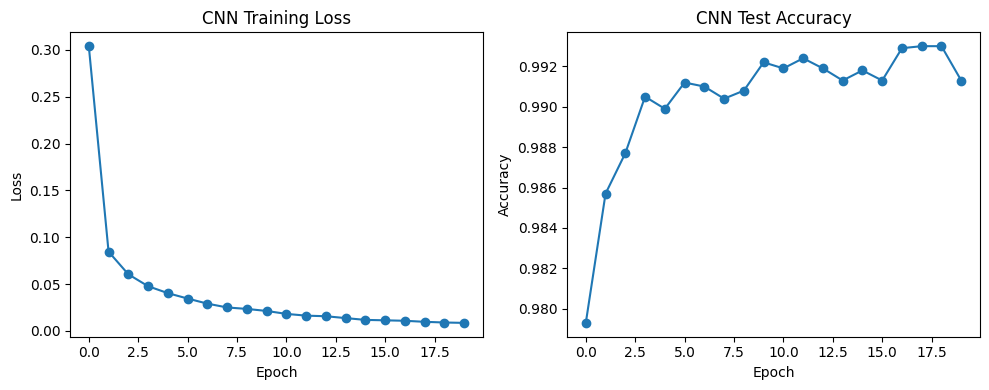

CNN accuracy: 0.9913
              precision    recall  f1-score   support

           0     0.9859    0.9969    0.9914       980
           1     0.9921    0.9991    0.9956      1135
           2     0.9941    0.9874    0.9908      1032
           3     0.9921    0.9970    0.9946      1010
           4     0.9939    0.9908    0.9924       982
           5     0.9899    0.9888    0.9893       892
           6     0.9927    0.9885    0.9906       958
           7     0.9864    0.9912    0.9888      1028
           8     0.9969    0.9897    0.9933       974
           9     0.9890    0.9822    0.9856      1009

    accuracy                         0.9913     10000
   macro avg     0.9913    0.9912    0.9912     10000
weighted avg     0.9913    0.9913    0.9913     10000



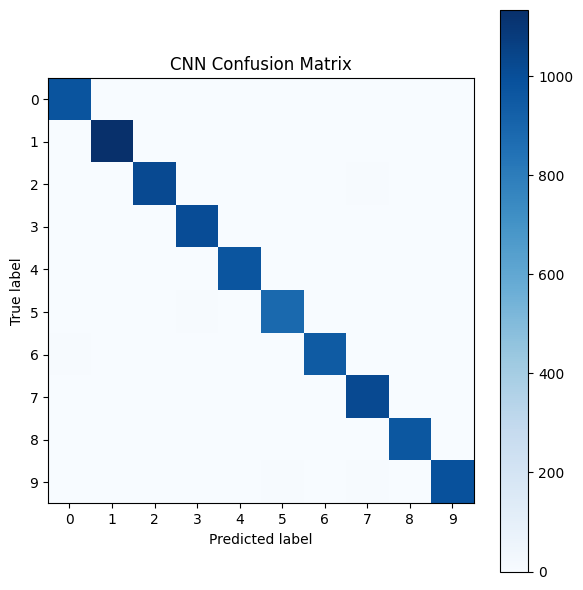

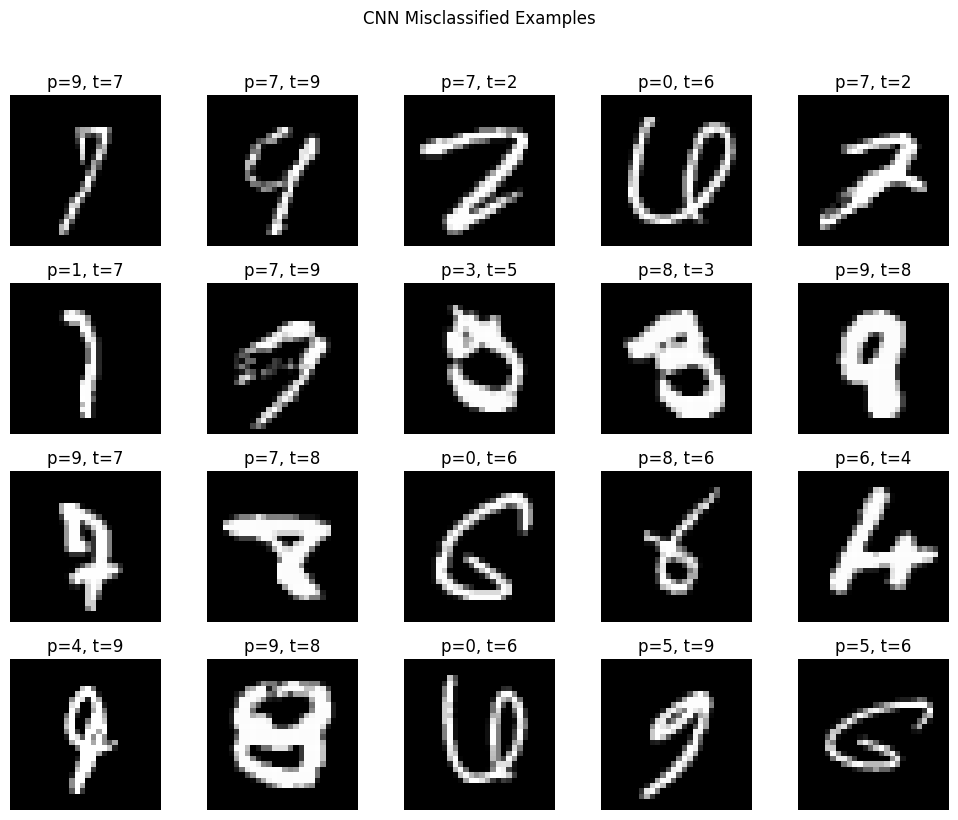

In [15]:
# Create datasets with full 2D image shape for convolutional layers
train_ds_img = TensorDataset(X_train_img, y_train_t)
test_ds_img = TensorDataset(X_test_img, y_test_t)

train_loader_img = DataLoader(train_ds_img, batch_size=batch_size, shuffle=True)
test_loader_img = DataLoader(test_ds_img, batch_size=batch_size, shuffle=False)


class SimpleCNN(nn.Module):
    """Two-block CNN with conv+ReLU+pool; classifier head with dropout."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),  # 28x28x1 -> 26x26x32
            nn.ReLU(),
            nn.MaxPool2d(2),  # 26x26x32 -> 13x13x32
            nn.Conv2d(32, 64, kernel_size=3),  # 13x13x32 -> 11x11x64
            nn.ReLU(),
            nn.MaxPool2d(2),  # 11x11x64 -> 5x5x64
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),              # 5*5*64 = 1600 features
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Dropout(0.25),          # Regularize the dense layer
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# Initialize CNN with same setup as MLP
cnn = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=1e-3)

epochs = 20
cnn_train_losses = []
cnn_test_accs = []

# Train and track progress (CNNs converge faster than MLPs)
for epoch in range(1, epochs + 1):
    loss = train_one_epoch(cnn, train_loader_img, criterion, optimizer, device)
    acc = evaluate_accuracy(cnn, test_loader_img, device)
    cnn_train_losses.append(loss)
    cnn_test_accs.append(acc)
    print(f"Epoch {epoch}/{epochs} - loss: {loss:.4f} - test acc: {acc:.4f}")

# Visualize training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_train_losses, marker="o")
plt.title("CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(cnn_test_accs, marker="o")
plt.title("CNN Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

# Collect predictions for full evaluation and error analysis
cnn.eval()
all_preds = []
all_true = []
with torch.no_grad():
    for batch_x, batch_y in test_loader_img:
        batch_x = batch_x.to(device)
        logits = cnn(batch_x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(batch_y.numpy())

y_pred_cnn = np.concatenate(all_preds)
y_true_cnn = np.concatenate(all_true)

acc_cnn = evaluate_classifier("CNN", y_true_cnn, y_pred_cnn)
results.append({
    "Model": "CNN",
    "Test Accuracy": acc_cnn,
    "Macro F1": f1_score(y_true_cnn, y_pred_cnn, average="macro"),
})

# Show CNN misclassifications (should be harder cases than linear model errors)
show_misclassified_examples(
    X_test,
    y_true_cnn,
    y_pred_cnn,
    n=20,
    title="CNN Misclassified Examples",
)

## Results summary

The table below compares test accuracy (and macro F1) across models.

In [16]:
# Sort models by test accuracy for easy comparison
# Higher accuracy ranks first; macro F1 is also tracked for balance across classes
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Test Accuracy,Macro F1
0,CNN,0.9913,0.991232
1,CNN,0.9895,0.989395
2,MLP,0.9833,0.983209
3,MLP,0.9774,0.977246
4,KNN (k=3),0.9705,0.970375
5,PCA(200) + Logistic Regression,0.9265,0.925469
6,Logistic Regression,0.9239,0.922777
7,SGD Classifier (log loss),0.9141,0.912625
8,Dummy (most frequent),0.1135,0.020386


Linear models already perform well because MNIST digits are centered and have consistent scale. Non-linear methods like KNN and the MLP improve accuracy, while the CNN performs best by leveraging spatial structure. The remaining mistakes are mostly between visually similar digits.

## Error analysis

We look at the most common confusions for the CNN and show examples. These highlight ambiguous handwriting or digits with similar shapes.

Top confusion pairs (true -> predicted, count):
5 -> 3: 8
2 -> 7: 6
8 -> 0: 6


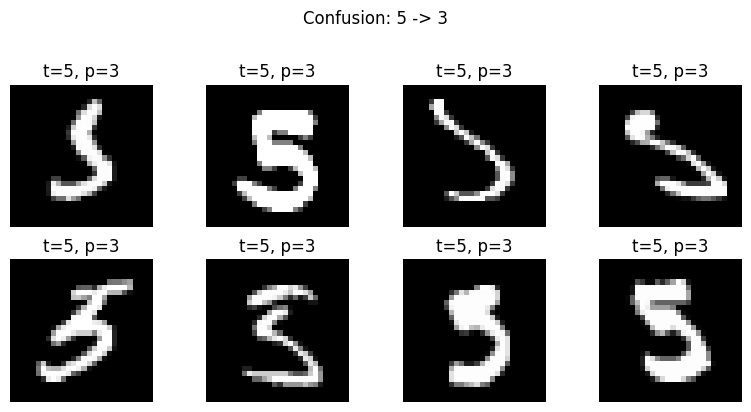

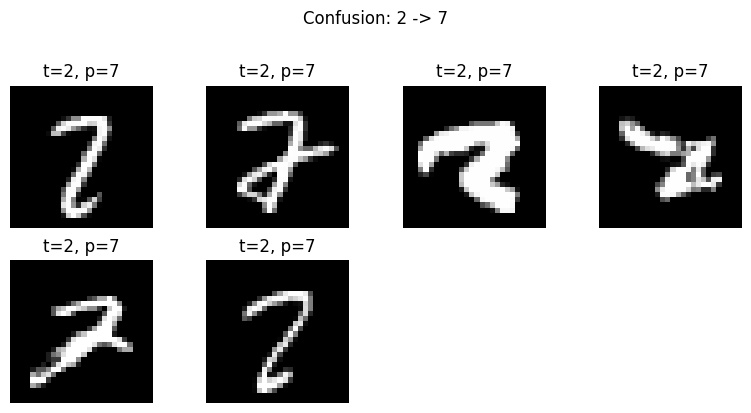

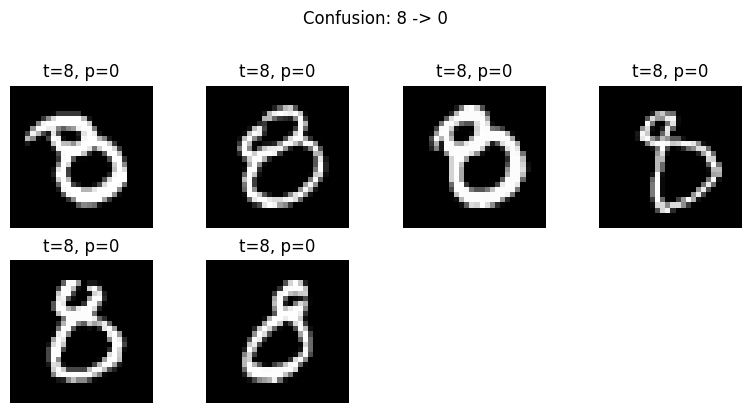

In [13]:
# Analyze CNN confusion patterns to understand remaining errors
cm = confusion_matrix(y_true_cnn, y_pred_cnn)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)  # Remove correct predictions from consideration

# Find the most common misclassifications (true label -> predicted label)
pairs = []
for true_label in range(10):
    for pred_label in range(10):
        if true_label != pred_label and cm_off[true_label, pred_label] > 0:
            pairs.append((true_label, pred_label, cm_off[true_label, pred_label]))

# Sort by count and take top 3 confusion pairs
pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
top_pairs = pairs[:3]

print("Top confusion pairs (true -> predicted, count):")
for t, p, c in top_pairs:
    print(f"{t} -> {p}: {c}")


def show_confusion_examples(images, y_true, y_pred, true_label, pred_label, n=8):
    """Show examples of a specific confusion to inspect ambiguous handwriting."""
    idx = np.where((y_true == true_label) & (y_pred == pred_label))[0]
    if len(idx) == 0:
        print(f"No examples for {true_label} -> {pred_label}.")
        return

    n = min(n, len(idx))
    chosen = idx[:n]

    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(8, 2 * rows))
    for i, image_idx in enumerate(chosen, start=1):
        plt.subplot(rows, cols, i)
        plt.imshow(images[image_idx], cmap="gray")
        plt.title(f"t={true_label}, p={pred_label}")
        plt.axis("off")
    plt.suptitle(f"Confusion: {true_label} -> {pred_label}", y=1.02)
    plt.tight_layout()
    plt.show()

# Show examples for each of the top confusion pairs
for true_label, pred_label, _ in top_pairs:
    show_confusion_examples(X_test, y_true_cnn, y_pred_cnn, true_label, pred_label, n=8)

## Conclusions

Centered digits and consistent scale make linear models surprisingly strong, which matches what we saw in EDA. Sparse strokes and prototype-like shapes help both KNN and the MLP, but overlapping shapes still cause confusion. CNNs reduce errors by using local patterns and translation tolerance, which lowers confusion for similar digits.

Next steps to explore:
- Data augmentation for slight shifts and rotations.
- A slightly larger CNN with batch normalization.
- Calibration or confidence estimates to understand uncertain predictions.